# Linear Regression Models — A Complete Guide

**Author:** Shivani Bokka  
**Dataset:** California Housing Dataset  
**Goal:** Predict house prices using various regression techniques

---

## What Is This Notebook About?

This notebook is a **complete walkthrough of regression models** — from the simplest to the more advanced. Each section explains the core idea in plain language before diving into the code.

Whether you're a student trying to understand machine learning for the first time, or a professional looking for a clean reference, this notebook has you covered.

---

## What Is Regression?

Imagine you want to **predict a number** — like the price of a house, the temperature tomorrow, or a person's salary. That's what regression does. It finds the relationship between **input features** (things we know) and a **continuous output** (the number we want to predict).

Think of it like this:  
> "If a house has 3 bedrooms, is 1500 sq ft, and is in a good neighborhood — what should it cost?"

Regression models learn this relationship from historical data, and then apply it to new examples.

---

## Models Covered in This Notebook

| # | Model | Key Idea |
|---|-------|----------|
| 1 | Multiple Linear Regression | Fit a straight line/plane to the data |
| 2 | Polynomial Regression | Fit curves instead of straight lines |
| 3 | Ridge Regression | Linear regression with L2 penalty to reduce overfitting |
| 4 | Lasso Regression | Linear regression with L1 penalty; can zero out features |
| 5 | ElasticNet Regression | Combination of Ridge and Lasso |
| 6 | KNN Regression | Predict based on nearest neighbors |
| 7 | Bayesian Linear Regression | Probabilistic take on linear regression |
| 8 | Support Vector Regression (SVR) | Find a tube that fits the data |

---

## Step 1 — Imports and Setup

Before anything else, we import all the tools we'll need throughout this notebook.

- **numpy / pandas** — for data manipulation
- **matplotlib / seaborn** — for visualization
- **sklearn** — the go-to machine learning library in Python

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


---

## Step 2 — Load and Explore the California Housing Dataset

### What Is This Dataset?

The **California Housing Dataset** comes from the 1990 US Census. Each row represents a **block group** (a small geographic area) in California. The goal is to predict the **median house value** for each block group.

### Features (the inputs we feed the model):

| Feature | What It Means |
|---------|---------------|
| MedInc | Median income of households in the block |
| HouseAge | Median age of houses in the block |
| AveRooms | Average number of rooms per household |
| AveBedrms | Average number of bedrooms per household |
| Population | Population of the block |
| AveOccup | Average number of household members |
| Latitude | Geographic latitude |
| Longitude | Geographic longitude |

### Target (what we want to predict):
- **MedHouseVal** — Median house value in $100,000s

In [82]:
# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0000,6.9841,1.0238,322.0000,2.5556,37.8800,-122.2300,4.5260
1,8.3014,21.0000,6.2381,0.9719,2401.0000,2.1098,37.8600,-122.2200,3.5850
2,7.2574,52.0000,8.2881,1.0734,496.0000,2.8023,37.8500,-122.2400,3.5210
3,5.6431,52.0000,5.8174,1.0731,558.0000,2.5479,37.8500,-122.2500,3.4130
4,3.8462,52.0000,6.2819,1.0811,565.0000,2.1815,37.8500,-122.2500,3.4220


In [83]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000
mean,3.8707,28.6395,5.4290,1.0967,1425.4767,3.0707,35.6319,-119.5697,2.0686
std,1.8998,12.5856,2.4742,0.4739,1132.4621,10.3860,2.1360,2.0035,1.1540
min,0.4999,1.0000,0.8462,0.3333,3.0000,0.6923,32.5400,-124.3500,0.1500
25%,2.5634,18.0000,4.4407,1.0061,787.0000,2.4297,33.9300,-121.8000,1.1960
50%,3.5348,29.0000,5.2291,1.0488,1166.0000,2.8181,34.2600,-118.4900,1.7970
75%,4.7432,37.0000,6.0524,1.0995,1725.0000,3.2823,37.7100,-118.0100,2.6472
max,15.0001,52.0000,141.9091,34.0667,35682.0000,1243.3333,41.9500,-114.3100,5.0000


In [84]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


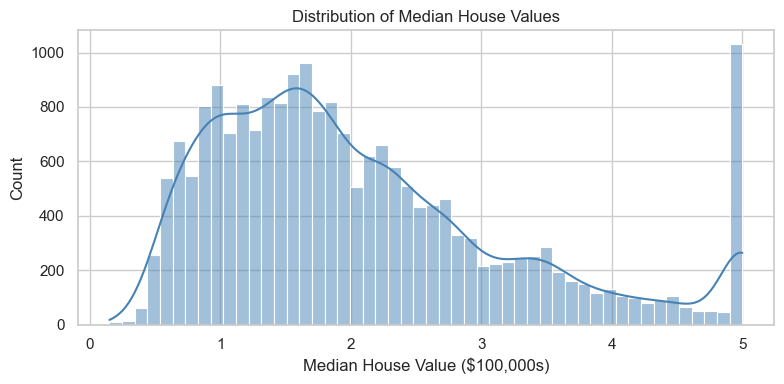

In [85]:
# Distribution of the target variable
plt.figure(figsize=(8, 4))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### How to Read This Chart: Distribution of House Values

This is a **histogram with a KDE (smoothed curve)** on top. Here's what to look for:

- **The bars (histogram)** show how many houses fall into each price range. Taller bars = more houses at that price.
- **The smooth curve (KDE)** shows the overall shape of the price distribution — it's like a smoothed version of the bars.
- **The x-axis** shows house values in units of $100,000. So a value of 2.0 means $200,000.
- **The y-axis** shows how many block groups fall into each bin.

**What this tells us:**
- Most houses are priced between $1 and $3 (i.e., $100K–$300K).
- There's a sharp spike at 5.0 — this is a **cap** in the dataset (houses above $500K were all recorded as $500K). This is worth noting, as it can affect model accuracy at the high end.
- The distribution is **right-skewed** — there are more cheap houses than expensive ones.

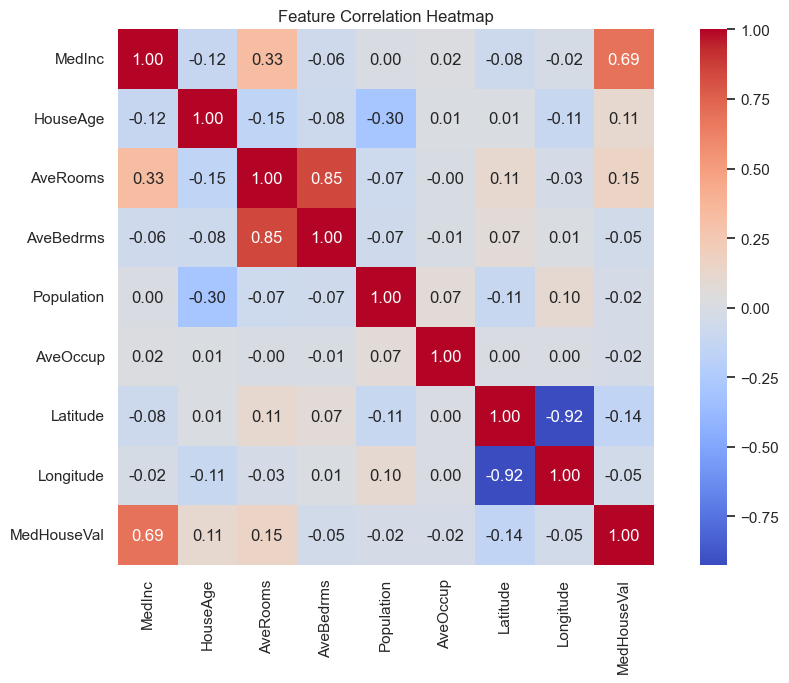

In [86]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### How to Read This Chart: Correlation Heatmap

A **correlation heatmap** shows how strongly each pair of variables is related to each other.

- **Each cell** contains a number between -1 and +1 called the **correlation coefficient**.
- **+1 (dark red)** = perfect positive relationship — when one goes up, the other goes up too.
- **-1 (dark blue)** = perfect negative relationship — when one goes up, the other goes down.
- **0 (white/light)** = no relationship at all.

**What to look for:**
- The **diagonal** (top-left to bottom-right) is always 1.0 — every feature is perfectly correlated with itself.
- Look at the **last row or column (MedHouseVal)** to see which features are most strongly related to the house price.
  - **MedInc** (median income) has the strongest positive correlation with house value — richer neighborhoods = higher prices.
  - **Latitude** has a negative correlation — generally, houses further north in California are cheaper.
- Cells with values close to 0 (light colors) mean those two features have little to do with each other.

> **Practical tip:** If two features are highly correlated with each other (not just with the target), it can cause problems in linear models. Ridge and Lasso help manage this.

---

## Step 3 — Prepare the Data

Before training any model, we need to:

1. **Split into features (X) and target (y)** — X is what we feed the model, y is what we want it to predict
2. **Split into training and test sets** — We train on 80% of data and test on the remaining 20%. This simulates predicting on data the model has never seen before.
3. **Scale the features** — Many models (like SVR, KNN, Ridge) are sensitive to the scale of input values. Scaling brings all features to a similar range so no single feature dominates.

In [87]:
# Separate features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")

Training set size: (16512, 8)
Test set size:     (4128, 8)


---

## Evaluation Metrics — How Do We Know If the Model Is Good?

We'll use three standard metrics throughout this notebook:

| Metric | What It Measures | Lower/Higher is Better? |
|--------|------------------|--------------------------|
| **MAE** (Mean Absolute Error) | Average absolute difference between predicted and actual values | Lower is better |
| **RMSE** (Root Mean Squared Error) | Like MAE but punishes large errors more severely | Lower is better |
| **R² Score** | How much of the variance in the target the model explains (1.0 = perfect) | Higher is better |

> **Analogy:** Imagine you're guessing the price of houses. MAE tells you your average error in dollars. RMSE penalizes you extra if you're wildly wrong on a few houses. R² tells you how well your guesses match the pattern in the data.

In [88]:
# Helper function to evaluate any regression model
results = {}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    
    print(f"--- {name} ---")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")
    print()
    return y_pred

# Helper function to plot actual vs predicted
def plot_predictions(y_test, y_pred, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none', s=10)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{title}\nActual vs Predicted')
    plt.legend()
    plt.tight_layout()
    plt.show()

---

# 1. Multiple Linear Regression

## What Is It?

**Multiple Linear Regression** is the most fundamental regression model. It extends simple linear regression (one input feature) to **multiple input features**.

The idea is simple:
> The model draws the **best-fitting straight line** (or hyperplane in multiple dimensions) through the data.

**Mathematically:**
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n$$

Where:
- $\hat{y}$ = predicted value (house price)
- $\beta_0$ = intercept (base price)
- $\beta_1 \ldots \beta_n$ = coefficients (how much each feature contributes)
- $x_1 \ldots x_n$ = input features (income, rooms, age, etc.)

## How Does It Learn?

It uses **Ordinary Least Squares (OLS)** — it finds the coefficients that **minimize the sum of squared differences** between predictions and actual values.

> Think of it like stretching a rubber band across a scatter plot so that it sits as close to all points as possible.

## When to Use It?
- When you believe there is a **linear relationship** between inputs and output
- As a **baseline model** to compare more complex models against
- When **interpretability** matters (you can directly see how each feature affects the prediction)

## Limitations
- Assumes linearity — can underfit complex relationships
- Sensitive to **outliers**
- Can **overfit** with many features (that's where Ridge/Lasso come in)

--- Multiple Linear Regression ---
  MAE  : 0.5332
  RMSE : 0.7456
  R²   : 0.5758



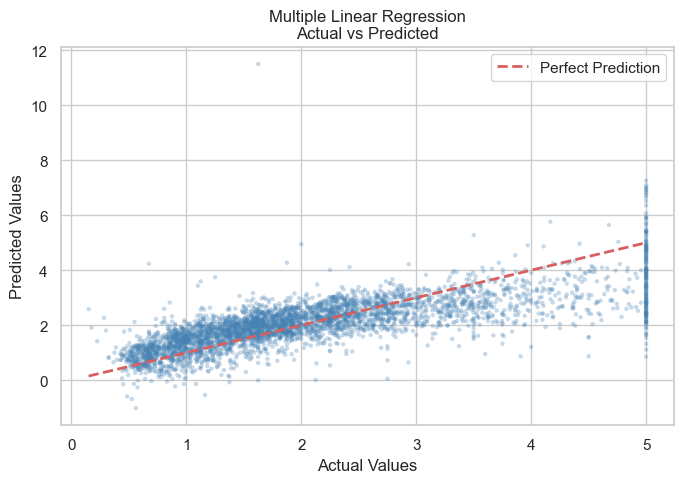

In [89]:
lr = LinearRegression()
y_pred_lr = evaluate_model('Multiple Linear Regression', lr, X_train_scaled, X_test_scaled, y_train, y_test)
plot_predictions(y_test, y_pred_lr, 'Multiple Linear Regression')

### How to Read This Chart: Actual vs Predicted

This is a **scatter plot** comparing the model's predictions to the real values.

- **Each dot** represents one house in the test set. Its x-position is the **actual price**, and its y-position is what the **model predicted**.
- **The red dashed line** is the "perfect prediction" line — if every dot sat exactly on this line, the model would be 100% accurate.
- **Dots close to the red line** = good predictions.
- **Dots far from the red line** = large errors.

**What to look for:**
- If the cloud of dots roughly follows the red line, the model is capturing the general trend well.
- If dots fan out more on the right side (higher actual values), the model struggles with expensive houses — which is common in linear regression.
- The flat row of dots at the top right (around y=5) reflects the price cap in the dataset — many houses were recorded as $500K regardless of their true value.

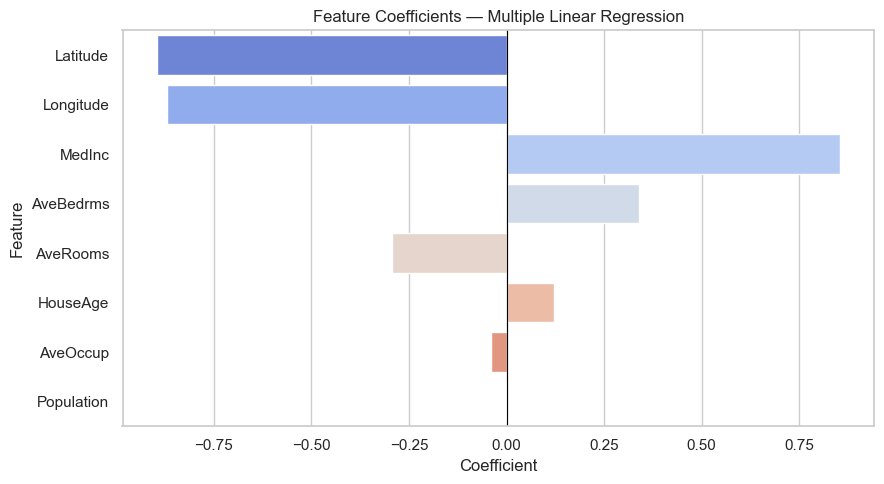


Interpretation:
Positive coefficients → feature increases house price
Negative coefficients → feature decreases house price


In [90]:
# Visualize feature coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Feature Coefficients — Multiple Linear Regression')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("Positive coefficients → feature increases house price")
print("Negative coefficients → feature decreases house price")

### How to Read This Chart: Feature Coefficients

This is a **horizontal bar chart** showing the coefficient the model assigned to each feature.

- **Each bar** represents one input feature (like MedInc, Latitude, etc.).
- **Bar length** = how much influence that feature has on the house price prediction.
- **Bars pointing right (positive)** = this feature pushes the predicted price UP. For example, higher median income → higher predicted house price.
- **Bars pointing left (negative)** = this feature pushes the predicted price DOWN. For example, higher latitude (further north in California) → lower predicted price.
- **The black vertical line at 0** is the dividing point between positive and negative effects.
- Features are sorted by the **size of their effect** (largest at top).

**What this tells us:**
- **MedInc** (median income) has the biggest positive effect — higher-income areas have more expensive houses.
- **Latitude and Longitude** have large negative effects — the geographic location strongly influences prices (coastal California is more expensive).
- Features with very small bars (near zero) barely affect the prediction.

---

# 2. Polynomial Regression

## What Is It?

Linear regression draws **straight lines**. But what if the relationship between your features and target is **curved**? That's where **Polynomial Regression** comes in.

> Think of it like this: if house prices first rise sharply with income, then level off, a straight line can't capture that. A curve can.

Polynomial regression **adds new features** that are powers of the original features:

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \ldots$$

The key insight: **it's still linear regression under the hood** — we just transform the input features first.

## The Degree Parameter

- **Degree 1** = plain linear regression
- **Degree 2** = adds squared terms (parabola-like curves)
- **Degree 3+** = more complex curves

**Warning:** Higher degrees can lead to **overfitting** — the model fits the training data perfectly but fails on new data.

## When to Use It?
- When you notice a **curved (non-linear) pattern** in your data
- When linear regression underfits but you don't want to switch to more complex models

## Limitations
- High-degree polynomials can **overfit dramatically**
- Feature count explodes quickly with many input variables and high degrees

--- Polynomial Regression (degree=2) ---
  MAE  : 0.4670
  RMSE : 0.6814
  R²   : 0.6457



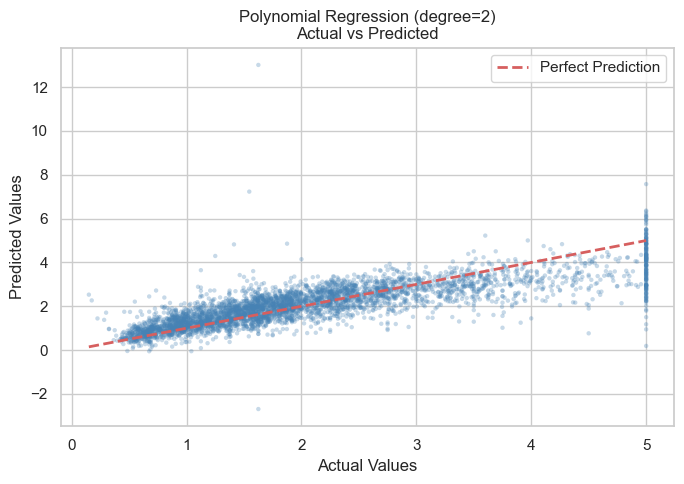

In [91]:
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

y_pred_poly = evaluate_model('Polynomial Regression (degree=2)', poly_pipeline, X_train, X_test, y_train, y_test)
plot_predictions(y_test, y_pred_poly, 'Polynomial Regression (degree=2)')

### How to Read This Chart: Polynomial Regression — Actual vs Predicted

Same format as the Linear Regression scatter plot — each dot is one test house, and the red dashed line is the perfect prediction line.

**Comparing to Linear Regression:**
- If the dots cluster more tightly around the red line than before, polynomial regression is capturing more of the non-linear patterns in the data.
- An R² closer to 1.0 means the curve explains more of the variation in house prices.
- Notice whether the scatter is more even across all price ranges — polynomial regression often improves predictions at both low and high ends of the price scale.

In [92]:
# Compare degrees
print("Comparing different polynomial degrees on R² score:\n")
for deg in [1, 2, 3]:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    r2_train = r2_score(y_train, pipe.predict(X_train))
    r2_test  = r2_score(y_test, pipe.predict(X_test))
    print(f"  Degree {deg}: Train R²={r2_train:.4f}  |  Test R²={r2_test:.4f}")

print("\nNotice how Train R² keeps rising but Test R² may drop — that's overfitting.")

Comparing different polynomial degrees on R² score:

  Degree 1: Train R²=0.6126  |  Test R²=0.5758
  Degree 2: Train R²=0.6853  |  Test R²=0.6457
  Degree 3: Train R²=0.7441  |  Test R²=-18.3887

Notice how Train R² keeps rising but Test R² may drop — that's overfitting.


### How to Read This Output: Degree Comparison

This table compares Train R² and Test R² for three polynomial degrees.

- **Train R²** = how well the model fits the data it was trained on.
- **Test R²** = how well the model predicts on data it has never seen.

**What to look for:**
- As degree increases, **Train R² keeps going up** — the model fits training data better and better.
- But **Test R² may start dropping** — the model memorizes the training data instead of learning general patterns. This is **overfitting**.
- **Degree 3** often shows a dramatic drop in Test R² (even going negative!), which means the model is making terrible predictions on new data despite fitting training data almost perfectly.

> **Golden rule:** A large gap between Train R² and Test R² is a sign of overfitting. Always trust Test R² more than Train R².

### Why Does the Actual vs Predicted Plot Look Straight?

You may have noticed that the **Actual vs Predicted scatter plot** for Polynomial Regression looks almost identical to the one for Linear Regression — both appear as a diagonal cloud of points, not a curve.

**This is expected, and here's why:**

The Actual vs Predicted plot puts the **true house price on the x-axis** and the **predicted house price on the y-axis**. In this space, any model that is doing a reasonable job will produce a roughly diagonal pattern — regardless of whether it is linear or polynomial internally.

The "curve" in polynomial regression refers to the shape of the **fit across a single input feature** (e.g., how price changes as income increases). To actually *see* that curve, you need to plot predictions against one feature while holding the others constant.

That is exactly what the chart below shows.

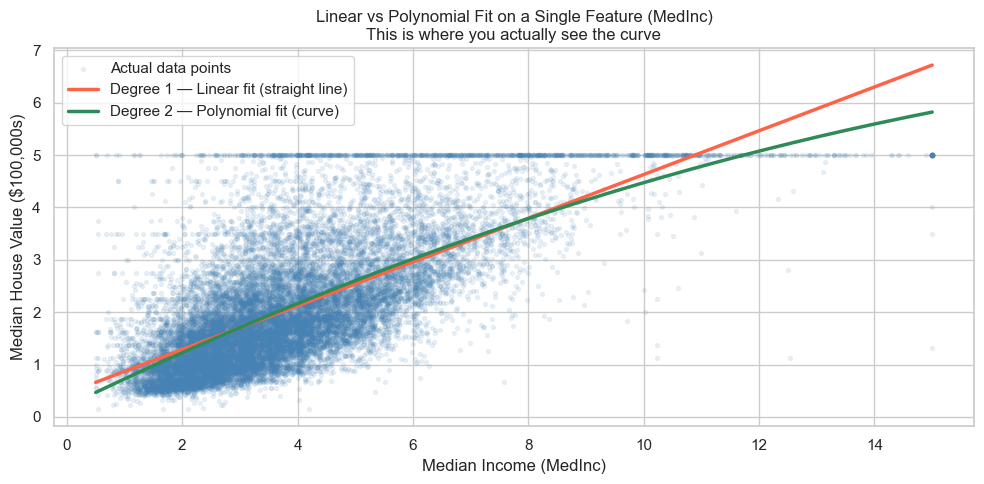

In [93]:
# Show the actual curve: Linear vs Polynomial fit on a single feature (MedInc)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Use only MedInc (median income) as the single feature for visualization
feature = 'MedInc'
X_single = df[[feature]].values
y_all = df['MedHouseVal'].values

# Sort by the feature for a smooth curve
sort_idx = np.argsort(X_single[:, 0])
X_sorted = X_single[sort_idx]
y_sorted = y_all[sort_idx]

# Fit degree 1 (linear) and degree 2 (polynomial)
line_model = LinearRegression().fit(X_sorted, y_sorted)
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
]).fit(X_sorted, y_sorted)

y_line = line_model.predict(X_sorted)
y_poly = poly_model.predict(X_sorted)

plt.figure(figsize=(10, 5))
plt.scatter(X_sorted, y_sorted, alpha=0.1, s=8, color='steelblue', label='Actual data points')
plt.plot(X_sorted, y_line, color='tomato', linewidth=2.5, label='Degree 1 — Linear fit (straight line)')
plt.plot(X_sorted, y_poly, color='seagreen', linewidth=2.5, label='Degree 2 — Polynomial fit (curve)')
plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Linear vs Polynomial Fit on a Single Feature (MedInc)\nThis is where you actually see the curve')
plt.legend()
plt.tight_layout()
plt.show()

### How to Read This Chart: Linear vs Polynomial Fit on a Single Feature

This is the chart that actually shows you **what polynomial regression is doing differently** from linear regression.

- **Each blue dot** is one house in the dataset. Its x-position is the median income of its neighborhood, and its y-position is the actual house price.
- **The red line** is the **degree 1 (linear) fit** — a perfectly straight line drawn through the data. Linear regression can only ever produce this kind of line.
- **The green curve** is the **degree 2 (polynomial) fit** — a curved line that is allowed to bend once. This is what polynomial regression actually learns.

**What to look for:**
- At **low income levels** (left side), both the red and green lines start in a similar place.
- As income increases (moving right), the **green curve bends** — it can follow the data more closely than the straight red line can.
- Notice how the data points are **not perfectly arranged in a straight line** — there is a slight curve to the overall trend. The polynomial fit picks this up; the linear fit cannot.
- The green curve is **not dramatically different** from the red line here, because this dataset is largely linear. In datasets with stronger curves (e.g., exponential growth), the difference would be much more pronounced.

> **Key insight:** The Actual vs Predicted plot looked straight because it was comparing predictions to true values — a diagnostic plot. *This* chart is the one that reveals the model's actual shape. Always plot your model's fit against individual features when you want to understand what shape it has learned.

---

# 3. Ridge Regression (L2 Regularization)

## What Is It?

Ridge Regression is **Linear Regression with a penalty**. It's designed to fix one of the biggest problems with plain linear regression: **overfitting**.

**The Problem with Plain Linear Regression:**  
When you have many features (or correlated features), linear regression can assign **huge coefficients** to some features, making the model very sensitive to small changes in data. This leads to poor performance on new data.

**Ridge's Solution:**  
It adds a **L2 penalty term** to the loss function:

$$\text{Loss} = \text{MSE} + \alpha \sum_{j=1}^{n} \beta_j^2$$

This forces the model to **keep coefficients small**, which reduces variance and improves generalization.

> **Real-world analogy:** Imagine you're guessing house prices and you rely too heavily on one neighborhood feature. Ridge says "don't bet everything on one feature — spread the weight around."

## The Alpha (α) Parameter

- **α = 0** → same as plain linear regression (no penalty)
- **α → very large** → all coefficients shrink toward zero (underfitting)
- **Best α** → found through cross-validation

## Key Property
Ridge **shrinks** coefficients but **never makes them exactly zero** — all features remain in the model.

--- Ridge Regression (alpha=1.0) ---
  MAE  : 0.5332
  RMSE : 0.7456
  R²   : 0.5758



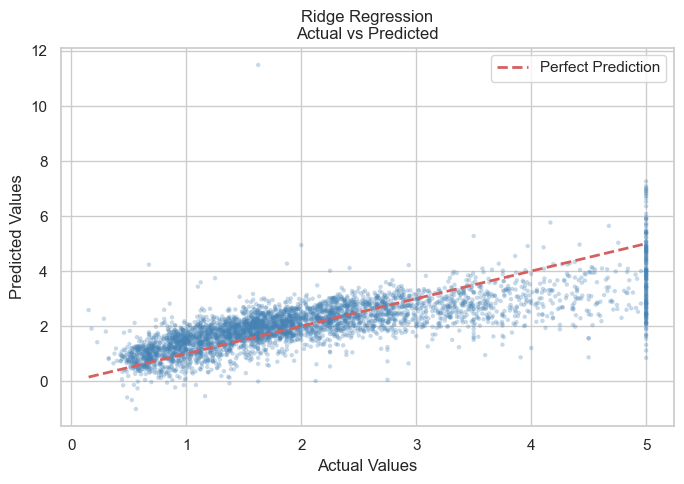

In [94]:
ridge = Ridge(alpha=1.0)
y_pred_ridge = evaluate_model('Ridge Regression (alpha=1.0)', ridge, X_train_scaled, X_test_scaled, y_train, y_test)
plot_predictions(y_test, y_pred_ridge, 'Ridge Regression')

### How to Read This Chart: Ridge — Actual vs Predicted

Same scatter plot format. Each dot is a test house. Red dashed line = perfect prediction.

**What to look for:**
- Ridge with a small alpha (like 1.0) often looks very similar to plain Linear Regression — the penalty is mild.
- The real benefit of Ridge shows up when features are correlated or when the training set is small. In those cases, Ridge will show a tighter scatter than plain Linear Regression.
- Compare the R² and RMSE with the Linear Regression results above — a small improvement is expected.

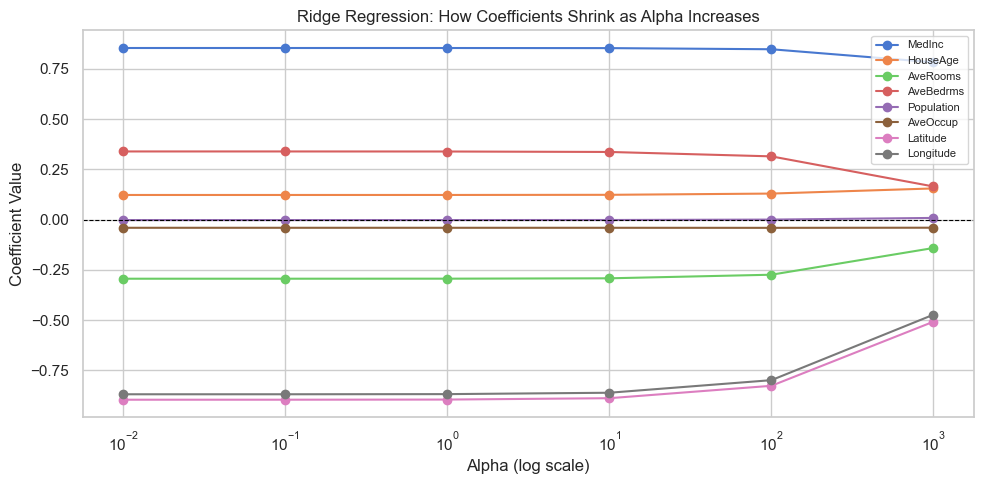


As alpha increases, all coefficients shrink toward 0 — but none reach exactly 0.


In [95]:
# Effect of alpha on Ridge coefficients
alphas = [0.01, 0.1, 1, 10, 100, 1000]
coef_matrix = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    coef_matrix.append(r.coef_)

coef_df_ridge = pd.DataFrame(coef_matrix, index=alphas, columns=X.columns)

plt.figure(figsize=(10, 5))
for col in X.columns:
    plt.plot(alphas, coef_df_ridge[col], marker='o', label=col)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: How Coefficients Shrink as Alpha Increases')
plt.legend(loc='upper right', fontsize=8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

print("\nAs alpha increases, all coefficients shrink toward 0 — but none reach exactly 0.")

### How to Read This Chart: Ridge Coefficient Path

This is called a **regularization path** — it shows what happens to each feature's coefficient as we increase the penalty strength (alpha).

- **The x-axis** is alpha on a log scale (0.01, 0.1, 1, 10, 100, 1000). Moving right = stronger penalty.
- **The y-axis** is the coefficient value for each feature.
- **Each colored line** represents one feature.
- **The dashed horizontal line at 0** is the reference — a coefficient of 0 means the feature has no effect.

**What to look for:**
- On the **left side** (low alpha), coefficients are large and spread out — similar to plain linear regression.
- As alpha increases (moving right), **all lines converge toward 0** — Ridge is squeezing all the coefficients down.
- Importantly, **no line ever reaches exactly 0** — Ridge keeps all features in the model, just with smaller weights.
- The features that take the longest to approach 0 (i.e., remain large even at high alpha) are the most important features.

---

# 4. Lasso Regression (L1 Regularization)

## What Is It?

Lasso (Least Absolute Shrinkage and Selection Operator) is similar to Ridge, but uses an **L1 penalty** instead:

$$\text{Loss} = \text{MSE} + \alpha \sum_{j=1}^{n} |\beta_j|$$

The key difference from Ridge? Lasso can make coefficients **exactly zero** — which means it **automatically selects features**.

> **Real-world analogy:** Imagine you're deciding which factors to include in a house price formula. Ridge keeps all factors but makes each one smaller. Lasso goes further — it **eliminates** the least useful factors entirely, giving you a simpler, more interpretable model.

## Ridge vs Lasso — Key Difference

| Property | Ridge (L2) | Lasso (L1) |
|----------|-----------|------------|
| Penalty term | Sum of squared coefficients | Sum of absolute coefficients |
| Zeros out features? | **No** | **Yes** |
| Feature selection | No | **Built-in** |
| Best when | Many small effects | Few large effects, many irrelevant features |

## When to Use Lasso?
- When you suspect **many features are irrelevant** or redundant
- When you want a **sparse, interpretable** model
- For **automatic feature selection**

--- Lasso Regression (alpha=0.01) ---
  MAE  : 0.5353
  RMSE : 0.7404
  R²   : 0.5816



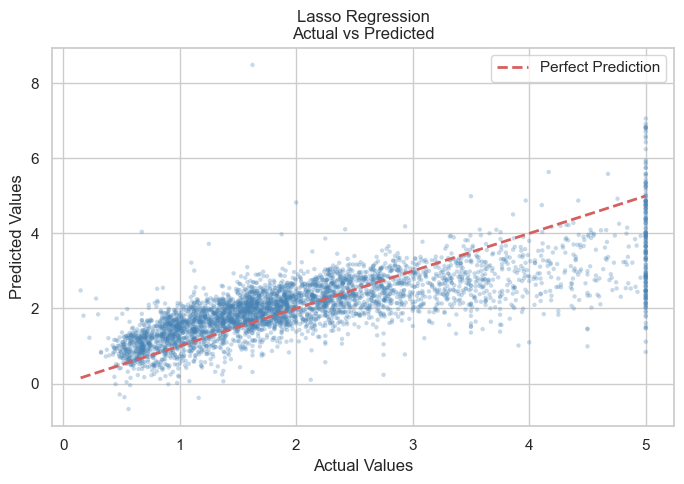

In [96]:
lasso = Lasso(alpha=0.01)
y_pred_lasso = evaluate_model('Lasso Regression (alpha=0.01)', lasso, X_train_scaled, X_test_scaled, y_train, y_test)
plot_predictions(y_test, y_pred_lasso, 'Lasso Regression')

### How to Read This Chart: Lasso — Actual vs Predicted

Same scatter plot format as before. Each dot = one test house. Red dashed line = perfect prediction.

**What to look for:**
- At a small alpha (like 0.01), Lasso behaves similarly to Linear Regression — just slightly regularized.
- The scatter pattern should be similar to Ridge at low alpha. The difference becomes visible in the coefficient chart below.
- If performance drops significantly compared to Linear Regression, alpha may be too high and too many features are being zeroed out.

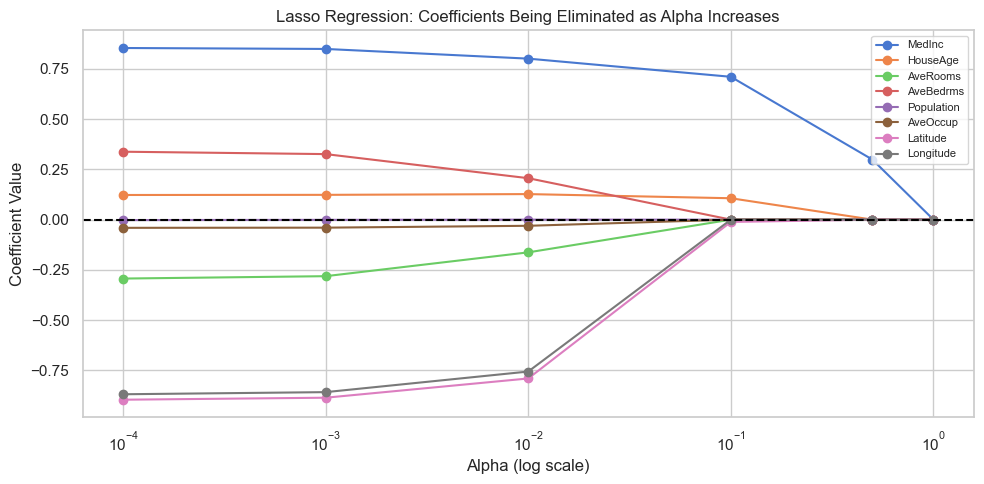


Notice: some coefficients hit exactly 0 — those features are excluded from the model.


In [97]:
# Visualize how Lasso zeros out features as alpha increases
alphas_lasso = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
coef_matrix_lasso = []

for a in alphas_lasso:
    l = Lasso(alpha=a, max_iter=10000).fit(X_train_scaled, y_train)
    coef_matrix_lasso.append(l.coef_)

coef_df_lasso = pd.DataFrame(coef_matrix_lasso, index=alphas_lasso, columns=X.columns)

plt.figure(figsize=(10, 5))
for col in X.columns:
    plt.plot(alphas_lasso, coef_df_lasso[col], marker='o', label=col)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression: Coefficients Being Eliminated as Alpha Increases')
plt.legend(loc='upper right', fontsize=8)
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.tight_layout()
plt.show()

print("\nNotice: some coefficients hit exactly 0 — those features are excluded from the model.")

### How to Read This Chart: Lasso Coefficient Path

Same structure as the Ridge path chart, but with a crucial difference.

- **The x-axis** is alpha (penalty strength) on a log scale — moving right = stronger penalty.
- **The y-axis** is each feature's coefficient value.
- **Each line** represents one feature.
- **The dashed line at 0** is the key reference.

**The critical difference from Ridge:**
- With Ridge, all lines gradually approach 0 but never touch it.
- With Lasso, lines **snap to exactly 0** at some point as alpha increases — meaning those features are completely removed from the model.
- Features that hit 0 first are the least useful ones. Features that stay non-zero the longest are the most important.

> **This is why Lasso is used for feature selection** — it literally tells you which features are worth keeping by zeroing out the rest.

---

# 5. ElasticNet Regression

## What Is It?

ElasticNet is the **best of both worlds** — it combines Ridge and Lasso regularization:

$$\text{Loss} = \text{MSE} + \alpha \left[ \rho \sum |\beta_j| + \frac{(1-\rho)}{2} \sum \beta_j^2 \right]$$

Where:
- **α** controls the overall strength of regularization
- **l1_ratio (ρ)** controls the mix:
  - `l1_ratio = 0` → pure Ridge
  - `l1_ratio = 1` → pure Lasso
  - `l1_ratio = 0.5` → equal mix of both

> **Real-world analogy:** Think of ElasticNet as a blended approach. Ridge keeps all features but makes them small. Lasso eliminates useless features. ElasticNet does both — it shrinks features AND can eliminate the worst ones.

## When to Use ElasticNet?
- When you have **highly correlated features** (Lasso can behave erratically here; ElasticNet handles it better)
- When you want **feature selection + smoothing** simultaneously
- When you're unsure whether Ridge or Lasso will work better — ElasticNet is a safe middle ground

--- ElasticNet Regression (alpha=0.01, l1_ratio=0.5) ---
  MAE  : 0.5341
  RMSE : 0.7416
  R²   : 0.5803



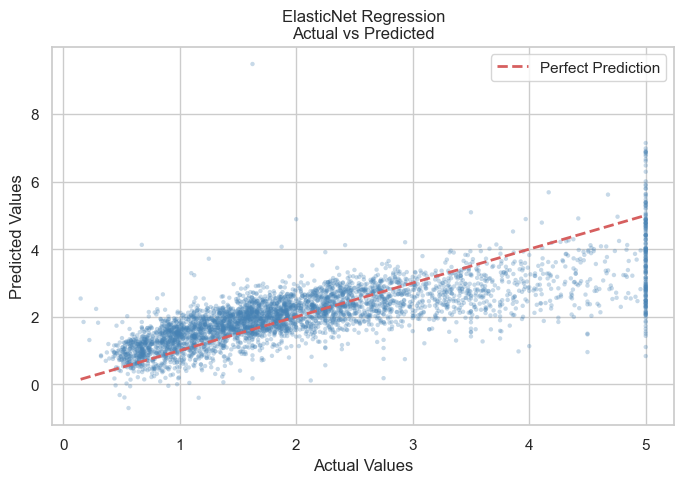

In [98]:
enet = ElasticNet(alpha=0.01, l1_ratio=0.5)
y_pred_enet = evaluate_model('ElasticNet Regression (alpha=0.01, l1_ratio=0.5)', enet, X_train_scaled, X_test_scaled, y_train, y_test)
plot_predictions(y_test, y_pred_enet, 'ElasticNet Regression')

### How to Read This Chart: ElasticNet — Actual vs Predicted

Same scatter plot format. Each dot = one house. Red dashed line = perfect prediction.

**What to look for:**
- ElasticNet's performance should fall somewhere between Ridge and Lasso, depending on the `l1_ratio` setting.
- An `l1_ratio` of 0.5 means equal parts Ridge and Lasso behavior — some features will be zeroed out, while others are just shrunk.
- Compare the R² and RMSE values to Ridge and Lasso above. If ElasticNet scores higher, it means the balance between both penalties is better suited for this dataset.

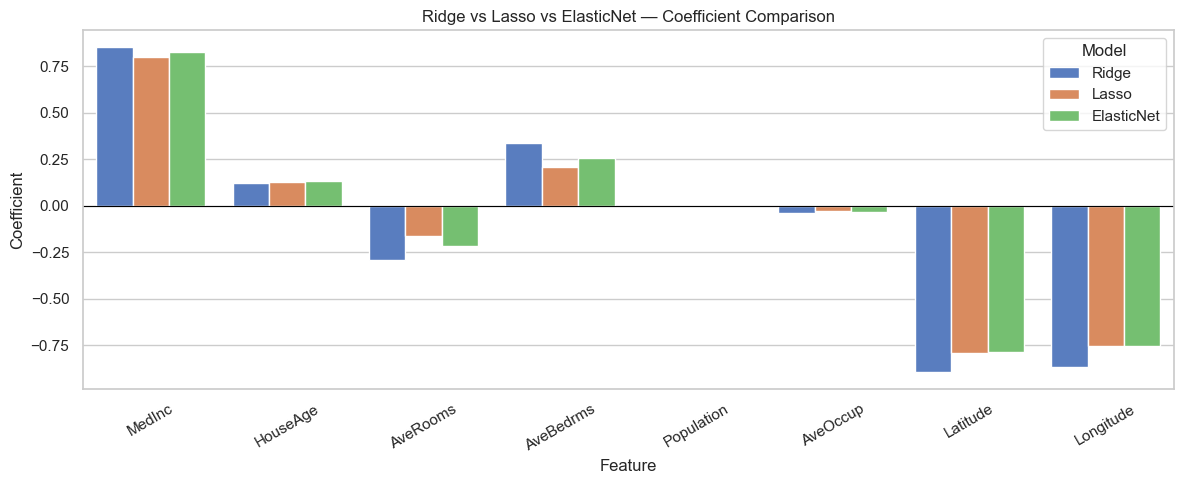

In [99]:
# Compare Ridge, Lasso, and ElasticNet coefficients side by side
ridge_model = Ridge(alpha=0.1).fit(X_train_scaled, y_train)
lasso_model = Lasso(alpha=0.01, max_iter=10000).fit(X_train_scaled, y_train)
enet_model  = ElasticNet(alpha=0.01, l1_ratio=0.5).fit(X_train_scaled, y_train)

coef_compare = pd.DataFrame({
    'Feature': X.columns,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_,
    'ElasticNet': enet_model.coef_
})

coef_compare_melted = coef_compare.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

plt.figure(figsize=(12, 5))
sns.barplot(data=coef_compare_melted, x='Feature', y='Coefficient', hue='Model')
plt.title('Ridge vs Lasso vs ElasticNet — Coefficient Comparison')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### How to Read This Chart: Ridge vs Lasso vs ElasticNet Coefficients

This **grouped bar chart** shows the coefficient each model assigned to each feature — all three models compared side by side.

- **Each group of bars** represents one feature.
- **The three colors** represent Ridge (blue), Lasso (orange), and ElasticNet (green).
- **Bar height** = how much importance that model gives to the feature. Taller bar = stronger influence.
- **Bars above 0** = positive effect (feature increases house price).
- **Bars below 0** = negative effect.
- **A bar at exactly 0** = Lasso or ElasticNet has eliminated that feature entirely.

**What to look for:**
- Ridge bars are always non-zero — Ridge never eliminates features.
- Lasso bars may be exactly zero for some features — those features are dropped.
- ElasticNet bars are in between — some features zeroed out, others shrunk but kept.
- Features where all three models agree (bars all positive or all negative) are the most reliably important features.

---

# 6. K-Nearest Neighbors Regression (KNN)

## What Is It?

KNN Regression is a **non-parametric** model — meaning it doesn't assume any particular shape for the relationship between inputs and outputs. Instead, it makes predictions purely based on **similarity**.

**How It Works:**
1. Given a new house, find the **K most similar houses** in the training data
2. Take the **average price** of those K neighbors
3. That's the predicted price!

> **Real-world analogy:** You want to price your house. You look at the 5 most similar houses in your neighborhood that recently sold, and take the average of their prices. That's exactly KNN.

## The K Parameter

- **K = 1** → Predict exactly the nearest neighbor's value. Very sensitive to noise (overfitting).
- **K = very large** → Average over many neighbors. Too smooth (underfitting).
- **Best K** → Usually found via cross-validation, often between 3–15.

## When to Use KNN?
- When the data has **no clear mathematical pattern** but similar instances behave similarly
- For **small to medium datasets** (it gets slow with large data)

## Limitations
- **Slow at prediction time** for large datasets (must compute distance to all training points)
- **Sensitive to feature scaling** — always scale before using KNN
- Struggles with **high-dimensional data** (curse of dimensionality)

--- KNN Regression (k=10) ---
  MAE  : 0.4403
  RMSE : 0.6493
  R²   : 0.6783



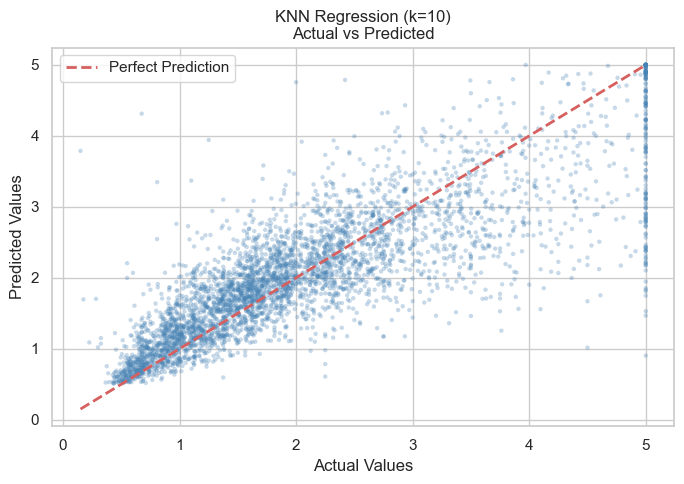

In [100]:
knn = KNeighborsRegressor(n_neighbors=10)
y_pred_knn = evaluate_model('KNN Regression (k=10)', knn, X_train_scaled, X_test_scaled, y_train, y_test)
plot_predictions(y_test, y_pred_knn, 'KNN Regression (k=10)')

### How to Read This Chart: KNN — Actual vs Predicted

Same scatter plot as before.

**What to look for:**
- KNN predictions tend to be **blockier** than linear models — they don't produce a smooth line, they produce stepped patterns because the prediction is always an average of a fixed set of neighbors.
- With K=10, the model averages 10 neighbors, which smooths out noise but may miss fine-grained patterns.
- If the scatter looks quite different from the linear models (e.g., more vertical scatter for a given actual value), it means KNN is finding different patterns than the linear approach.
- Look at the upper-right area — KNN often struggles with capped values (at 5.0) the same way linear models do.

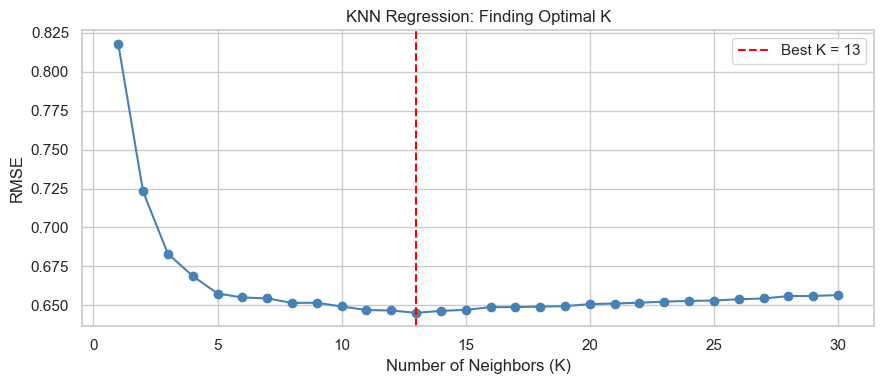

Best K = 13 with RMSE = 0.6452


In [101]:
# Finding the optimal K
k_values = range(1, 31)
rmse_scores = []

for k in k_values:
    knn_k = KNeighborsRegressor(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    y_pred_k = knn_k.predict(X_test_scaled)
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred_k)))

best_k = k_values[np.argmin(rmse_scores)]

plt.figure(figsize=(9, 4))
plt.plot(k_values, rmse_scores, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('RMSE')
plt.title('KNN Regression: Finding Optimal K')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best K = {best_k} with RMSE = {min(rmse_scores):.4f}")

### How to Read This Chart: Finding the Best K

This **line chart** shows how prediction error (RMSE) changes as we try different values of K.

- **The x-axis** is the number of neighbors K (from 1 to 30).
- **The y-axis** is RMSE — lower is better.
- **The red dashed vertical line** marks the K value that gave the lowest RMSE (best performance).

**What to look for:**
- At **K=1** (far left), RMSE is usually high — the model is overfitting, basing predictions on just one neighbor which may be an outlier.
- As K increases, RMSE generally **drops at first** — averaging more neighbors reduces noise.
- At very **large K**, RMSE may start climbing again — the model is too smooth, averaging over too many dissimilar houses.
- The **sweet spot** is usually somewhere in the middle — where the curve bottoms out. The red line shows you this optimal K.

> **Practical takeaway:** Don't just use the default K=5. Always run this kind of search to find the best K for your specific dataset.

---

# 7. Bayesian Linear Regression

## What Is It?

Bayesian Linear Regression is a **probabilistic version of linear regression**. Instead of finding a single "best" line, it finds a **distribution of possible lines** and quantifies **uncertainty** in its predictions.

**The Bayesian Mindset:**
- Classical regression says: "The best slope is 3.2."
- Bayesian regression says: "The slope is most likely around 3.2, but it could reasonably be anywhere from 2.8 to 3.6."

> **Real-world analogy:** Two appraisers estimate a house at $400K. The first says "$400K, final answer." The second says "I'm confident it's $400K, but given the uncertainty in the market, it's probably between $370K and $430K." The second is the Bayesian approach — more honest about what we don't know.

## Key Concepts

- **Prior** — Our belief about the coefficients *before* seeing the data
- **Likelihood** — How well the model explains the data we see
- **Posterior** — Our updated belief *after* combining prior + data

## When to Use It?
- When you want to **quantify uncertainty** in predictions
- When you have **small datasets** (Bayesian methods shine here)
- When you want **built-in regularization** without manual hyperparameter tuning

--- Bayesian Linear Regression ---
  MAE  : 0.5332
  RMSE : 0.7455
  R²   : 0.5758



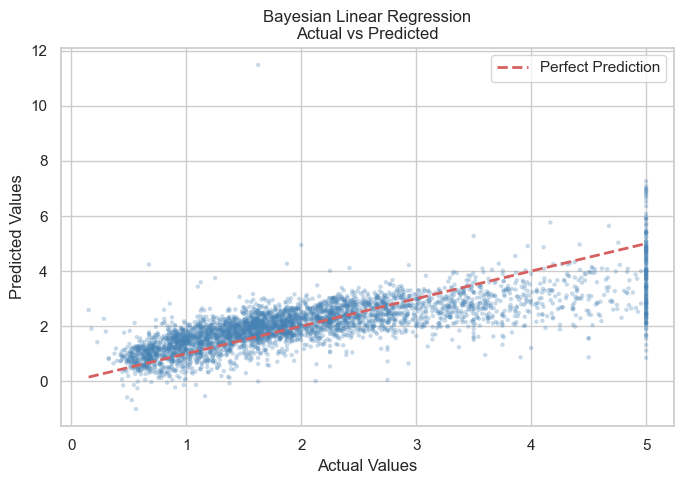

In [102]:
bayes = BayesianRidge()
y_pred_bayes = evaluate_model('Bayesian Linear Regression', bayes, X_train_scaled, X_test_scaled, y_train, y_test)
plot_predictions(y_test, y_pred_bayes, 'Bayesian Linear Regression')

### How to Read This Chart: Bayesian — Actual vs Predicted

Same scatter plot format.

**What to look for:**
- Bayesian Ridge often produces results very similar to plain Ridge regression, since it automatically finds a good regularization level.
- The real advantage of Bayesian regression shows in the next chart (uncertainty intervals), not just in point accuracy.
- Compare its R² and RMSE to Ridge — they should be close, which confirms that BayesianRidge is effectively finding a similar level of regularization automatically.

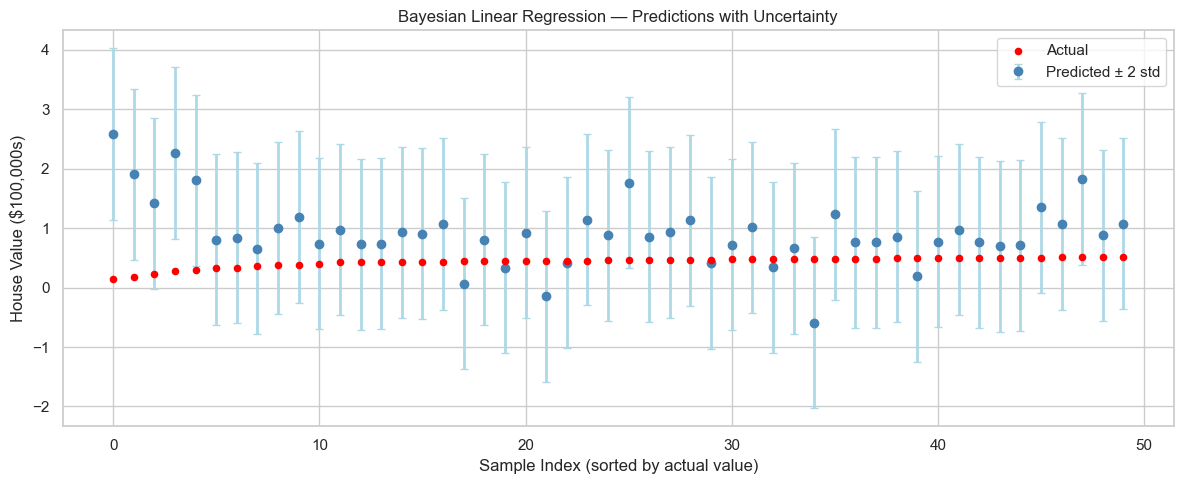


The error bars represent uncertainty — wider bars mean the model is less confident.


In [103]:
# Bayesian Ridge: Prediction with uncertainty intervals
bayes_fitted = BayesianRidge().fit(X_train_scaled, y_train)
y_pred_mean, y_pred_std = bayes_fitted.predict(X_test_scaled, return_std=True)

# Sample 50 test points for visualization
n_show = 50
indices = np.argsort(y_test.values)[:n_show]

plt.figure(figsize=(12, 5))
plt.errorbar(
    range(n_show),
    y_pred_mean[indices],
    yerr=2 * y_pred_std[indices],
    fmt='o',
    color='steelblue',
    ecolor='lightblue',
    elinewidth=2,
    capsize=3,
    label='Predicted ± 2 std'
)
plt.scatter(range(n_show), y_test.values[indices], color='red', zorder=5, s=20, label='Actual')
plt.title('Bayesian Linear Regression — Predictions with Uncertainty')
plt.xlabel('Sample Index (sorted by actual value)')
plt.ylabel('House Value ($100,000s)')
plt.legend()
plt.tight_layout()
plt.show()

print("\nThe error bars represent uncertainty — wider bars mean the model is less confident.")

### How to Read This Chart: Uncertainty Intervals

This chart is unique to Bayesian regression — it shows not just **what** the model predicted, but **how confident** it is in each prediction.

- **The x-axis** is simply the index of 50 sample houses, sorted from cheapest to most expensive (left = cheap, right = expensive).
- **The y-axis** is the house value.
- **Each blue dot** is the model's predicted price.
- **The blue vertical error bars** show the range of uncertainty (± 2 standard deviations). This means the model is saying "I'm about 95% confident the true price falls within this range."
- **Each red dot** is the actual real price.

**What to look for:**
- When the **red dot falls inside the blue error bars** → the model's uncertainty range successfully captured the true value.
- **Wider error bars** = the model is less confident about that prediction (maybe the house is unusual).
- **Narrower error bars** = the model is more confident.
- If many red dots fall outside the bars, the model may be underestimating its own uncertainty.

> **Why this matters in the real world:** In risk-sensitive applications (like loan approval or medical decisions), knowing how uncertain a prediction is can be just as important as the prediction itself.

---

# 8. Support Vector Regression (SVR)

## What Is It?

Support Vector Regression (SVR) comes from the family of **Support Vector Machines (SVM)** — one of the most powerful and mathematically elegant ML algorithms.

**The Core Idea:**  
Instead of minimizing the error for all predictions, SVR tries to fit a **"tube" around the data** of width ε (epsilon). Points *inside* the tube are considered close enough and are **not penalized**. Only points *outside* the tube contribute to the loss.

> **Real-world analogy:** Imagine you're pricing houses. You're okay being off by $20K — that's within your acceptable margin. SVR only worries about predictions that are more than $20K off, and ignores small errors. This makes it very robust to noise.

## The Math

SVR solves the following optimization problem:

$$\text{Minimize} \quad \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^*)$$

Subject to:

$$y_i - \langle w, x_i \rangle - b \leq \varepsilon + \xi_i$$
$$\langle w, x_i \rangle + b - y_i \leq \varepsilon + \xi_i^*$$
$$\xi_i, \xi_i^* \geq 0$$

In plain English:
- **w** = the model's weights (what it learns)
- **ε (epsilon)** = the half-width of the tolerance tube — errors smaller than ε are completely ignored
- **ξ and ξ\*** = slack variables — they measure how far a point sticks out *above or below* the tube
- **C** = how much to penalize points that fall outside the tube. High C = tight fit, low C = wider tolerance

The model tries to keep the tube as flat (small w) as possible, while also keeping as many points inside the tube as possible.

## Does Epsilon Get Chosen Automatically?

**No — you must set epsilon yourself.** sklearn's SVR defaults to `epsilon=0.1`, which means the tube is always fixed at ±0.1 units wide (in the target's scale). The model only learns where to *position* the tube, not how wide to make it. Choosing epsilon requires domain knowledge — it should reflect how much prediction error you are willing to tolerate.

## Key Parameters

| Parameter | What It Controls | Do you set it? |
|-----------|------------------|----------------|
| **C** | Penalty for errors outside the tube — higher C = tighter fit | Yes (default=1.0) |
| **epsilon (ε)** | Half-width of the tolerance tube — errors within ε are ignored | **Yes — you must choose this** |
| **kernel** | Mathematical function used to map data (`rbf`, `linear`, `poly`) | Yes (default=`rbf`) |

## The Kernel Trick
SVR can model **non-linear relationships** using the **kernel trick** — it transforms the data into a higher-dimensional space where a linear tube can fit it, without ever explicitly computing that transformation.

## When to Use SVR?
- When you have **small to medium datasets** with complex relationships
- When you want **robustness to outliers** (thanks to the epsilon-insensitive zone)
- When the data is **non-linear** (use `kernel='rbf'`)

## Limitations
- **Slow** on large datasets
- Requires careful **hyperparameter tuning** (C, epsilon, kernel)
- Less interpretable than linear models

--- Support Vector Regression (RBF kernel) ---
  MAE  : 0.3986
  RMSE : 0.5975
  R²   : 0.7276



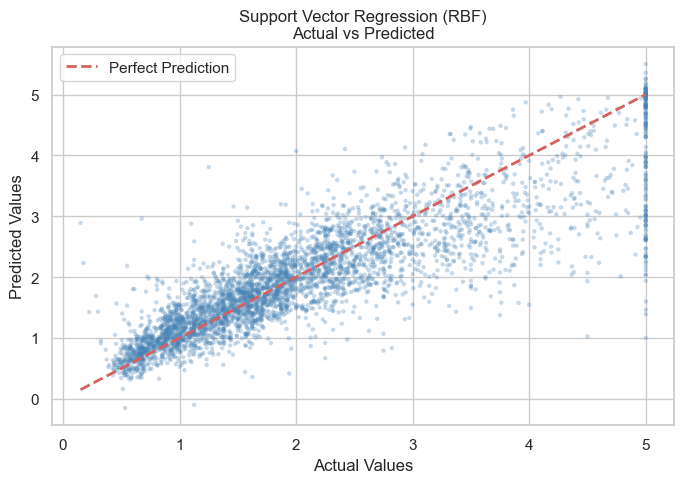

In [104]:
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
y_pred_svr = evaluate_model('Support Vector Regression (RBF kernel)', svr, X_train_scaled, X_test_scaled, y_train, y_test)
plot_predictions(y_test, y_pred_svr, 'Support Vector Regression (RBF)')

### How to Read This Chart: SVR — Actual vs Predicted

Same scatter plot format — each dot is a test house, red dashed line is the perfect prediction.

**What to look for:**
- SVR with an RBF kernel can capture non-linear patterns, so the scatter may look different from the linear models.
- Look for whether extreme values (very cheap or very expensive houses) are handled better — SVR's epsilon tube means it ignores small errors and focuses on the worst cases.
- If the overall scatter is tighter around the red line compared to linear regression, SVR is picking up non-linear patterns that the linear models missed.

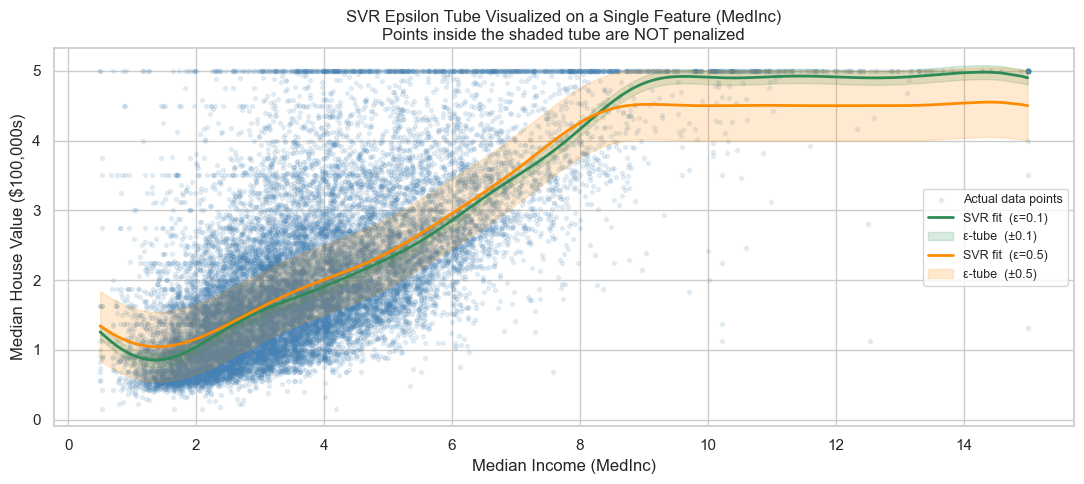

In [105]:
# Visualize the SVR epsilon tube on a single feature (MedInc)
feature = 'MedInc'
X_single = df[[feature]].values
y_all = df['MedHouseVal'].values

# Sort for a smooth curve
sort_idx = np.argsort(X_single[:, 0])
X_sorted = X_single[sort_idx]
y_sorted = y_all[sort_idx]

# Scale just this one feature
from sklearn.preprocessing import StandardScaler
scaler_single = StandardScaler()
X_sorted_scaled = scaler_single.fit_transform(X_sorted)

# Fit SVR with two different epsilons so students can compare
epsilon_vals = [0.1, 0.5]
colors = ['seagreen', 'darkorange']

plt.figure(figsize=(11, 5))
plt.scatter(X_sorted, y_sorted, alpha=0.12, s=8, color='steelblue', label='Actual data points')

for eps, col in zip(epsilon_vals, colors):
    svr_plot = SVR(kernel='rbf', C=1.0, epsilon=eps)
    svr_plot.fit(X_sorted_scaled, y_sorted)
    y_fit = svr_plot.predict(X_sorted_scaled)

    plt.plot(X_sorted, y_fit, color=col, linewidth=2,
             label=f'SVR fit  (ε={eps})')
    plt.fill_between(X_sorted[:, 0],
                     y_fit - eps,
                     y_fit + eps,
                     alpha=0.18, color=col,
                     label=f'ε-tube  (±{eps})')

plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('SVR Epsilon Tube Visualized on a Single Feature (MedInc)\n'
          'Points inside the shaded tube are NOT penalized')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

### How to Read This Chart: The SVR Epsilon Tube

This chart is the clearest way to see what makes SVR fundamentally different from every other regression model in this notebook.

- **Each blue dot** is one house in the dataset. x-axis = median income of its neighborhood, y-axis = actual house price.
- **The solid colored lines** are the SVR's predicted values (the centre of the tube) for two different epsilon settings.
- **The shaded bands** around each line are the **epsilon tubes** — the ±ε zone around the prediction.

**The most important rule of SVR:**
- Any data point that falls **inside the shaded band** is treated as a perfect prediction. The model does not care how far inside the band the point is — it contributes **zero** to the loss.
- Any data point that falls **outside the shaded band** does contribute to the loss, and the model tries to minimize those errors.

**Comparing the two epsilon values:**
- **ε = 0.1 (narrow green tube):** A tight tolerance. Only points very close to the line are ignored. More points fall outside, so the model works harder and the curve fits the data more closely.
- **ε = 0.5 (wider orange tube):** A loose tolerance. Many more points fall inside the band and are completely ignored. The model only adjusts for the most extreme outliers, resulting in a smoother but less precise curve.

**What to look for:**
- Notice how the orange tube is much wider — a large portion of the data points sit inside it and are simply disregarded by the model.
- The green (ε=0.1) curve hugs the data more closely because fewer points are inside its narrow tube, so it has to adjust more.
- Choosing epsilon is a trade-off: **too small** = the model tries to fit every noisy point (overfitting risk); **too large** = the model ignores too much and underfits.

> **Key takeaway:** Epsilon is **not learned automatically** — you set it based on how much prediction error is acceptable in your problem. For house prices in units of $100,000s, an epsilon of 0.1 means you tolerate errors up to $10,000, while 0.5 means up to $50,000.

In [106]:
# Compare SVR kernels
print("Comparing SVR kernels:\n")
for kernel in ['linear', 'poly', 'rbf']:
    svr_k = SVR(kernel=kernel, C=1.0)
    svr_k.fit(X_train_scaled, y_train)
    r2 = r2_score(y_test, svr_k.predict(X_test_scaled))
    rmse = np.sqrt(mean_squared_error(y_test, svr_k.predict(X_test_scaled)))
    print(f"  Kernel={kernel:6s}: R²={r2:.4f}  RMSE={rmse:.4f}")

Comparing SVR kernels:

  Kernel=linear: R²=0.5579  RMSE=0.7611
  Kernel=poly  : R²=0.2341  RMSE=1.0018
  Kernel=rbf   : R²=0.7276  RMSE=0.5975


### How to Read This Output: SVR Kernel Comparison

This table compares three SVR kernels on the same dataset.

- **linear kernel** — SVR with a straight boundary (similar to linear regression but with the epsilon tube).
- **poly kernel** — SVR with a polynomial boundary (can capture curves). **Note:** the poly kernel is the most sensitive to data scale and dataset size — it can behave erratically on small samples and may need extra tuning (`degree`, `coef0`) to perform well. Don't be surprised if it underperforms here.
- **rbf kernel** — SVR with a radial basis function (can capture complex, non-linear boundaries). This is the most commonly used and most reliable kernel.

**What to look for:**
- The kernel with the **highest R²** and **lowest RMSE** is the best choice for this dataset.
- `rbf` is almost always competitive or the best — it is the safe default for SVR.
- If `linear` performs nearly as well as `rbf`, the data is mostly linear and simpler models (like Ridge) may be preferable — faster and more interpretable.
- If `poly` performs poorly, it does not mean polynomial patterns don't exist — it usually just means the kernel needs its own tuning (`degree` and `coef0` parameters) before it can compete.

---

# Final Comparison — All Models

## Putting It All Together

Now that we've trained all 8 regression models, let's compare them side by side. This is exactly what you'd do in a real machine learning project — train multiple models and pick the one that performs best on the test set.

**Remember:** The "best" model is context-dependent:
- If **interpretability** matters → prefer Linear Regression, Ridge, or Lasso
- If **raw performance** matters → SVR or Polynomial Regression might win
- If **uncertainty quantification** matters → Bayesian is the choice

In [107]:
# Build comparison table
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'MAE', 'RMSE', 'R²']
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)

print("Model Performance Comparison (sorted by R²):\n")
print(results_df.to_string(index=False))

Model Performance Comparison (sorted by R²):

                                           Model    MAE   RMSE     R²
          Support Vector Regression (RBF kernel) 0.3986 0.5975 0.7276
                           KNN Regression (k=10) 0.4403 0.6493 0.6783
                Polynomial Regression (degree=2) 0.4670 0.6814 0.6457
                   Lasso Regression (alpha=0.01) 0.5353 0.7404 0.5816
ElasticNet Regression (alpha=0.01, l1_ratio=0.5) 0.5341 0.7416 0.5803
                      Bayesian Linear Regression 0.5332 0.7455 0.5758
                    Ridge Regression (alpha=1.0) 0.5332 0.7456 0.5758
                      Multiple Linear Regression 0.5332 0.7456 0.5758


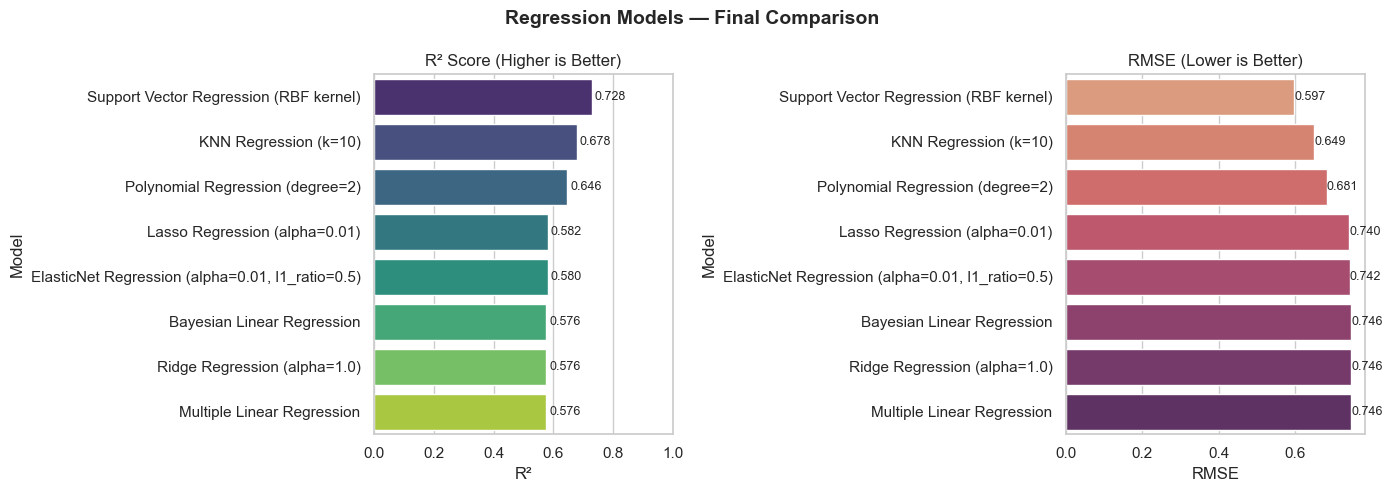

In [108]:
# Visual comparison — R² Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² bar chart
sns.barplot(data=results_df, x='R²', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('R² Score (Higher is Better)')
axes[0].set_xlim(0, 1)
for bar, val in zip(axes[0].patches, results_df['R²']):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# RMSE bar chart
sns.barplot(data=results_df, x='RMSE', y='Model', palette='flare', ax=axes[1])
axes[1].set_title('RMSE (Lower is Better)')
for bar, val in zip(axes[1].patches, results_df['RMSE']):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Regression Models — Final Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Final Model Comparison

This **side-by-side bar chart** is the summary of everything we've done — it shows how all 8 models rank against each other.

**Left chart — R² Score (Higher is Better):**
- **The x-axis** goes from 0 to 1. A bar reaching 1.0 would be a perfect model.
- **Each bar** represents one model. Longer bar = better.
- **The number at the end of each bar** is the exact R² score.
- Models are sorted from best to worst (top to bottom), so the best model is at the top.

**Right chart — RMSE (Lower is Better):**
- **Shorter bar = better** (less error).
- RMSE is in the same units as the target variable (house prices in $100,000s). So an RMSE of 0.7 means the model is off by about $70,000 on average.

**What to look for:**
- Which model consistently performs best on both charts?
- Is there a big jump between the top model and the others, or are they all bunched closely together?
- A small gap between models means any of them could work well — you might choose the simpler one (like Ridge) for interpretability.
- A large gap means the top model is genuinely better and worth the added complexity.

> **Key insight:** A high R² combined with a low RMSE = the model is both explaining the data well and making small errors. That's what we're always aiming for.

---

# Summary and Key Takeaways

## What Did We Learn?

| Model | Strength | Best Use Case |
|-------|----------|---------------|
| **Multiple Linear Regression** | Simple, fast, interpretable | Baseline; data with linear patterns |
| **Polynomial Regression** | Captures curves | Datasets with non-linear but smooth patterns |
| **Ridge (L2)** | Handles multicollinearity | Many correlated features; keeps all of them |
| **Lasso (L1)** | Built-in feature selection | High-dimensional data with many irrelevant features |
| **ElasticNet** | Best of Ridge + Lasso | Correlated features + need for feature selection |
| **KNN Regression** | No assumptions about data shape | Small datasets with local patterns |
| **Bayesian Linear Regression** | Uncertainty quantification | Small data; risk-sensitive applications |
| **SVR** | Robust to outliers, flexible kernels | Complex non-linear patterns; medium-sized data |

---

## The Golden Rule in Model Selection

> **Always start simple.** Begin with linear regression, establish a baseline, then try more complex models. Complexity doesn't always mean better.

---

## What's Next?

- Explore **classification models** in the companion notebook: `logistic_regression_models.ipynb`
- Try **GridSearchCV** to tune hyperparameters for the best alpha, K, or C values
- Explore **ensemble methods** (Random Forest, XGBoost) in the separate ensemble models repo